Load data (alarm)

In [1]:
from pgmpy.utils import get_example_model

# Load  dataset
true_model = get_example_model("alarm")

# Simulate continuous gene expression data
alarm_df = true_model.simulate(1000)

print("Dataset shape:", alarm_df.shape)

/Users/nunu/Documents/Masterthesis/thesisenv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Generating for node: BP: 100%|██████████| 37/37 [00:00<00:00, 679.72it/s]

Dataset shape: (1000, 37)


In [2]:
from pgmpy.estimators import HillClimbSearch, BIC

# Initialize search object
hc = HillClimbSearch(alarm_df)

# Use BIC score for continuous data
best_model = hc.estimate(
    scoring_method=BIC(alarm_df),
    max_indegree=3
)

print("Learned edges:", len(best_model.edges()))

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'PAP': 'C', 'ERRLOWOUTPUT': 'C', 'STROKEVOLUME': 'C', 'HYPOVOLEMIA': 'C', 'DISCONNECT': 'C', 'LVFAILURE': 'C', 'HREKG': 'C', 'ANAPHYLAXIS': 'C', 'HR': 'C', 'SAO2': 'C', 'BP': 'C', 'INSUFFANESTH': 'C', 'EXPCO2': 'C', 'VENTLUNG': 'C', 'SHUNT': 'C', 'FIO2': 'C', 'MINVOLSET': 'C', 'LVEDVOLUME': 'C', 'INTUBATION': 'C', 'VENTTUBE': 'C', 'HISTORY': 'C', 'CVP': 'C', 'ERRCAUTER': 'C', 'TPR': 'C', 'VENTALV': 'C', 'CATECHOL': 'C', 'KINKEDTUBE': 'C', 'CO': 'C', 'VENTMACH': 'C', 'ARTCO2': 'C', 'MINVOL': 'C', 'HRSAT': 'C', 'PCWP': 'C', 'PULMEMBOLUS': 'C', 'HRBP': 'C', 'PRESS': 'C', 'PVSAT': 'C'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'PAP': 'C', 'ERRLOWOUTPUT': 'C', 'STROKEVOLUME': 'C', 'HYPOVOLEMIA': 'C', 'DISCONNECT': 'C', 'LVFAILURE': 'C', 'HREKG': 'C', 'ANAPHYLAXIS': 'C', 'HR': 'C', 'SAO2': 'C', 'BP': 'C', 'INSUFFANESTH': 'C'

Learned edges: 44


In [3]:
true_edges = set(true_model.edges())
learned_edges = set(best_model.edges())

true_positives = len(true_edges & learned_edges)
false_positives = len(learned_edges - true_edges)
false_negatives = len(true_edges - learned_edges)

precision = true_positives / (true_positives + false_positives + 1e-9)
recall = true_positives / (true_positives + false_negatives + 1e-9)

print(f"True edges: {len(true_edges)}")
print(f"Learned edges: {len(learned_edges)}")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")

True edges: 46
Learned edges: 44
Precision: 0.500
Recall: 0.478


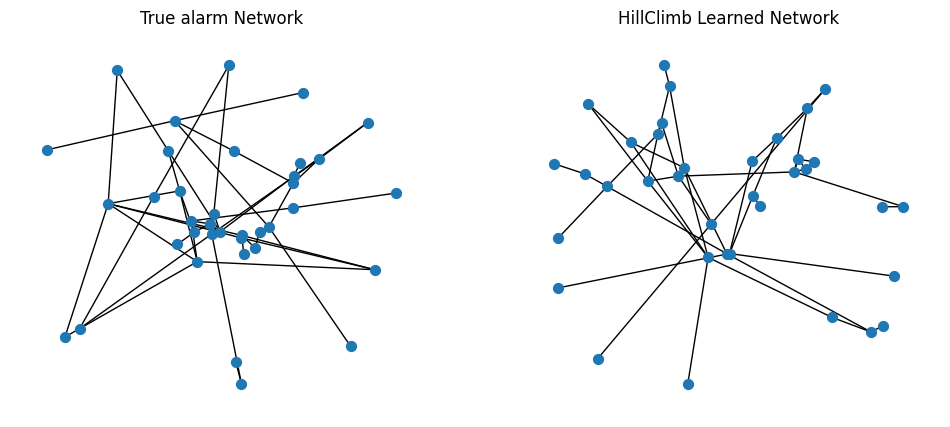

In [4]:
import networkx as nx
import matplotlib.pyplot as plt

G_true = nx.DiGraph()
G_true.add_edges_from(true_model.edges())

G_hc = nx.DiGraph()
G_hc.add_edges_from(best_model.edges())

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
pos = nx.spring_layout(G_true, seed=42)
nx.draw(G_true, pos, node_size=50, arrows=False)
plt.title("True alarm Network")

plt.subplot(1, 2, 2)
pos2 = nx.spring_layout(G_hc, seed=42)
nx.draw(G_hc, pos2, node_size=50, arrows=False)
plt.title("HillClimb Learned Network")

plt.show()